In [9]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score,average_precision_score,classification_report
from sklearn.tree import DecisionTreeClassifier

X, y = make_classification(
    n_samples=80_000,
    n_features=25,
    n_informative=12,
    n_redundant=5,
    weights=[0.99, 0.01],
    flip_y=0.01,
    random_state=42
)
print(f"Fraud rate: {y.mean()*100:.2f}%")


Fraud rate: 1.50%


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_v_s  = scaler.transform(X_val)

overfit_tree = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
    # max_depth=None by default
)
overfit_tree.fit(X_tr_s, y_train)

y_p_t=overfit_tree.predict_proba(X_tr_s)[:,1]
y_p_v=overfit_tree.predict_proba(X_v_s)[:,1]
train_pr = average_precision_score(
    y_train,y_p_t)
val_pr = average_precision_score(
    y_val, y_p_v)

y_pred=overfit_tree.predict(X_v_s)

print(classification_report(y_val, y_pred, digits=4))
print(f"Train PR-AUC : {train_pr:.4f}")
print(f"Val   PR-AUC : {val_pr:.4f}")
print(f"Overfit gap  : {train_pr - val_pr:.4f}")
print(f"Tree depth   : {overfit_tree.get_depth()}")
print(f"Leaf count   : {overfit_tree.get_n_leaves()}")

              precision    recall  f1-score   support

           0     0.9868    0.9866    0.9867     15760
           1     0.1317    0.1333    0.1325       240

    accuracy                         0.9738     16000
   macro avg     0.5592    0.5600    0.5596     16000
weighted avg     0.9740    0.9738    0.9739     16000

Train PR-AUC : 1.0000
Val   PR-AUC : 0.0306
Overfit gap  : 0.9694
Tree depth   : 64
Leaf count   : 1876


Optimal max_depth : 8
Best val PR-AUC   : 0.0731


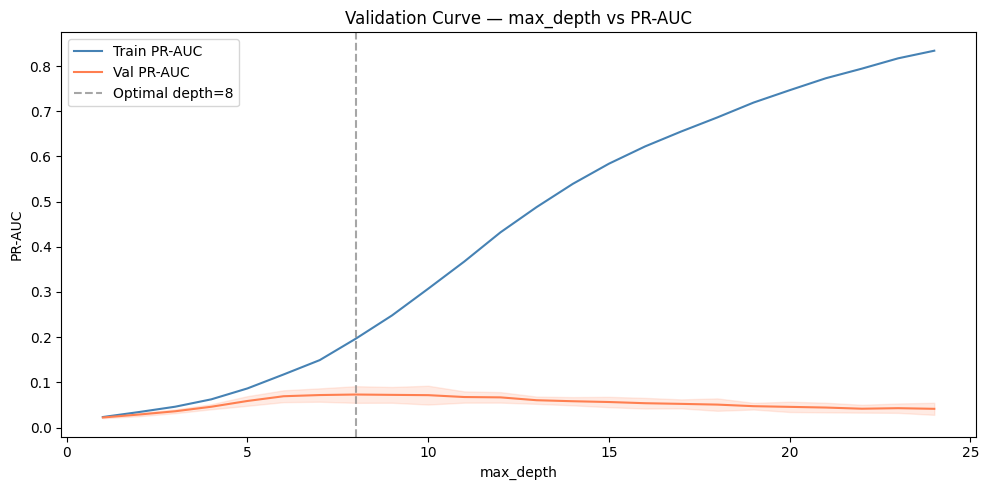

Optimal min_samples_leaf: 20


In [15]:
from sklearn.model_selection import validation_curve, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

depth_range = np.arange(1, 25)

train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(
        class_weight='balanced', random_state=42),
    X_train, y_train,
    param_name='max_depth',
    param_range=depth_range,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

optimal_depth = depth_range[np.argmax(val_mean)]
print(f"Optimal max_depth : {optimal_depth}")
print(f"Best val PR-AUC   : {val_mean.max():.4f}")

plt.figure(figsize=(10, 5))
plt.plot(depth_range, train_mean, label='Train PR-AUC',
         color='steelblue')
plt.plot(depth_range, val_mean,   label='Val PR-AUC',
         color='coral')
plt.fill_between(depth_range,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.15, color='coral')
plt.axvline(optimal_depth, color='gray', linestyle='--',
            alpha=0.7, label=f'Optimal depth={optimal_depth}')
plt.xlabel('max_depth')
plt.ylabel('PR-AUC')
plt.title('Validation Curve — max_depth vs PR-AUC')
plt.legend()
plt.tight_layout()
plt.show()

# Now repeat for min_samples_leaf
leaf_range = np.array([1, 5, 10, 20, 50, 100, 200, 500])

train_lf, val_lf = validation_curve(
    DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=optimal_depth,
        random_state=42),
    X_train, y_train,
    param_name='min_samples_leaf',
    param_range=leaf_range,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1
)

optimal_leaf = leaf_range[np.argmax(val_lf.mean(axis=1))]
print(f"Optimal min_samples_leaf: {optimal_leaf}")

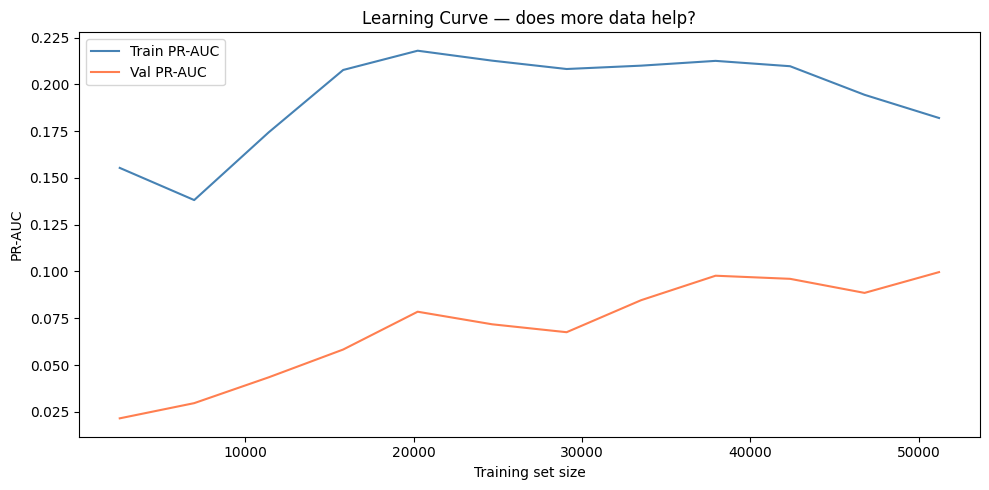

In [16]:
from sklearn.model_selection import learning_curve

train_sizes_abs, train_lc, val_lc = learning_curve(
    DecisionTreeClassifier(
        max_depth=optimal_depth,
        min_samples_leaf=optimal_leaf,
        class_weight='balanced',
        random_state=42
    ),
    X_train, y_train,
    train_sizes=np.linspace(0.05, 1.0, 12),
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='average_precision',
    n_jobs=-1
)

train_lc_mean = train_lc.mean(axis=1)
val_lc_mean   = val_lc.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes_abs, train_lc_mean,
         label='Train PR-AUC', color='steelblue')
plt.plot(train_sizes_abs, val_lc_mean,
         label='Val PR-AUC',   color='coral')
plt.xlabel('Training set size')
plt.ylabel('PR-AUC')
plt.title('Learning Curve — does more data help?')
plt.legend()
plt.tight_layout()
plt.show()

# Reading the learning curve:
# Val curve still rising steeply at rightmost point
#   → more data will help, keep collecting
# Val curve flat but low, small train-val gap
#   → high bias, change model architecture
# Large train-val gap even with lots of data
#   → high variance, regularise more first

In [17]:
# now parameterized Decsisoin Tree

In [21]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, average_precision_score

best_tree = DecisionTreeClassifier(
    max_depth=optimal_depth,
    min_samples_leaf=optimal_leaf,
    min_samples_split=max(10, optimal_leaf * 2),
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
best_tree.fit(X_tr_s, y_train)

y_pred  = best_tree.predict(X_v_s)
y_proba = best_tree.predict_proba(X_v_s)[:, 1]

y_p_t=overfit_tree.predict_proba(X_tr_s)[:,1]
y_p_v=overfit_tree.predict_proba(X_v_s)[:,1]
train_pr = average_precision_score(
    y_train,y_p_t)
val_pr = average_precision_score(
    y_val, y_p_v)

print(f"Train PR-AUC : {train_pr:.4f}")
print(f"Val   PR-AUC : {val_pr:.4f}")


print("=== REGULARISED TREE ===")
print(classification_report(y_val, y_pred, digits=4))
print(f"PR-AUC : {average_precision_score(y_val, y_proba):.4f}")
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
print(f"TP={tp} | FP={fp} | FN={fn} | TN={tn}")
print(f"Catch rate: {tp/(tp+fn):.4f}")

Train PR-AUC : 1.0000
Val   PR-AUC : 0.0306
=== REGULARISED TREE ===
              precision    recall  f1-score   support

           0     0.9913    0.7289    0.8401     15760
           1     0.0315    0.5792    0.0598       240

    accuracy                         0.7266     16000
   macro avg     0.5114    0.6540    0.4499     16000
weighted avg     0.9769    0.7266    0.8284     16000

PR-AUC : 0.0916
TP=139 | FP=4273 | FN=101 | TN=11487
Catch rate: 0.5792


In [ ]:
#-------visualizaing Tree-------

|--- feat_5 <= 1.15
|   |--- feat_0 <= 1.17
|   |   |--- feat_3 <= 0.85
|   |   |   |--- feat_16 <= 0.14
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- feat_16 >  0.14
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- feat_3 >  0.85
|   |   |   |--- feat_2 <= 0.60
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- feat_2 >  0.60
|   |   |   |   |--- truncated branch of depth 5
|   |--- feat_0 >  1.17
|   |   |--- feat_24 <= -0.99
|   |   |   |--- feat_18 <= -0.54
|   |   |   |   |--- class: 0
|   |   |   |--- feat_18 >  -0.54
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- feat_24 >  -0.99
|   |   |   |--- feat_22 <= -0.34
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- feat_22 >  -0.34
|   |   |   |   |--- truncated branch of depth 5
|--- feat_5 >  1.15
|   |--- feat_16 <= 0.22
|   |   |--- feat_2 <= 1.45
|   |   |   |--- feat_20 <= 0.98
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- feat_

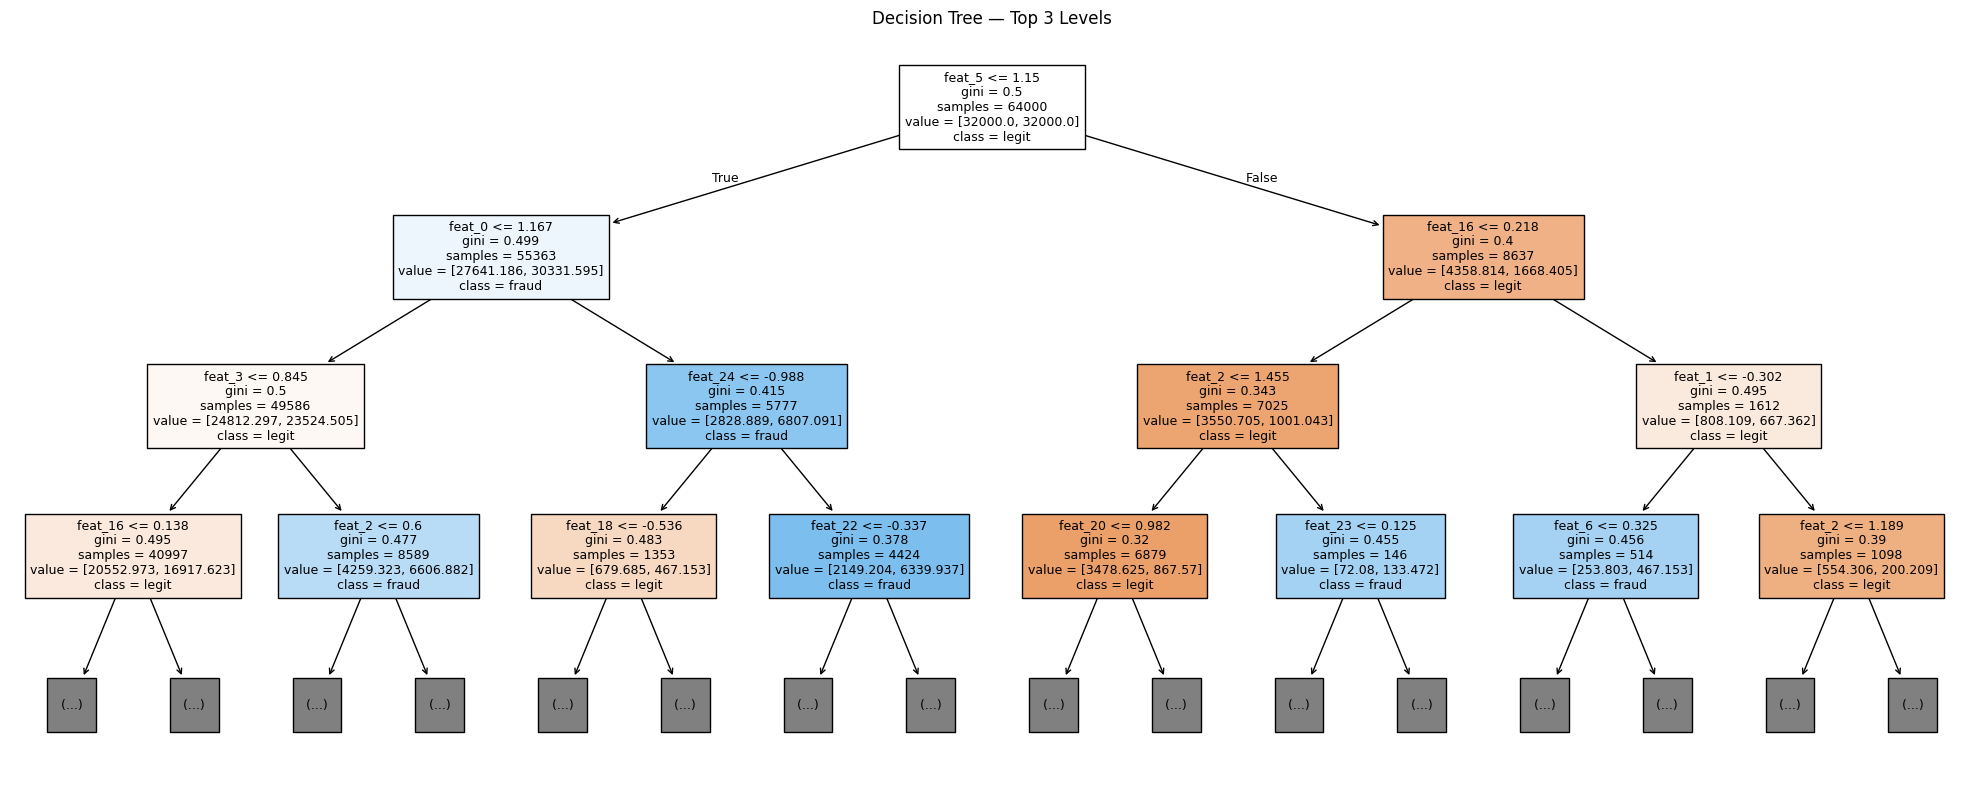

In [22]:
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

tree_rules = export_text(
    best_tree,
    feature_names=[f'feat_{i}' for i in range(X_train.shape[1])],
    max_depth=3
)
print(tree_rules)

plt.figure(figsize=(20, 8))
plot_tree(
    best_tree,
    feature_names=[f'feat_{i}' for i in range(X_train.shape[1])],
    class_names=['legit', 'fraud'],
    filled=True,
    max_depth=3,
    fontsize=9
)
plt.title('Decision Tree — Top 3 Levels')
plt.tight_layout()
plt.show()

# What to look for:
# Does the root split make domain sense?
# Are fraud-dominated leaves being isolated cleanly?
# Does any split fire on an irrelevant feature? = possible leakage


In [23]:
#---feature importance and why it can mislead

In [24]:
import pandas as pd

feat_names = [f'feat_{i}' for i in range(X_train.shape[1])]
importances = pd.Series(
    best_tree.feature_importances_, index=feat_names)
print("Top 10 feature importances:")
print(importances.sort_values(ascending=False).head(10).round(4))

# Red flags:
# Single feature with >0.5 importance = possible leakage
# Feature you know is irrelevant appears in top 5 = investigate
# All importances roughly equal = model using noise features

# Permutation importance — more honest
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    best_tree, X_v_s, y_val,
    n_repeats=10,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1
)
perm_series = pd.Series(perm_imp.importances_mean, index=feat_names)
print("\nTop 10 permutation importances:")
print(perm_series.sort_values(ascending=False).head(10).round(4))

Top 10 feature importances:
feat_5     0.1391
feat_16    0.1122
feat_3     0.0931
feat_2     0.0774
feat_0     0.0755
feat_19    0.0627
feat_1     0.0595
feat_18    0.0569
feat_13    0.0484
feat_6     0.0448
dtype: float64

Top 10 permutation importances:
feat_3     0.0456
feat_2     0.0450
feat_1     0.0336
feat_19    0.0286
feat_0     0.0281
feat_15    0.0263
feat_5     0.0246
feat_22    0.0165
feat_18    0.0132
feat_24    0.0121
dtype: float64


In [25]:
#  GridSearchCV   that automatically chooses the best hypermater by testing all combos of hyperparameters it tests each combo on each cross validation

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':         [3, 4, 5, 6, 8],
    'min_samples_leaf':  [10, 20, 50, 100],
    'min_samples_split': [20, 50, 100],
    'max_features':      ['sqrt', 0.5, None],
}

gs = GridSearchCV(
    DecisionTreeClassifier(
        class_weight='balanced', random_state=42),
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='average_precision',
    n_jobs=-1,
    refit=True,
    verbose=1
)
gs.fit(X_tr_s, y_train)

print(f"Best params   : {gs.best_params_}")
print(f"Best CV PR-AUC: {gs.best_score_:.4f}")

best_gs_model = gs.best_estimator_
y_proba_gs = best_gs_model.predict_proba(X_v_s)[:, 1]
print(f"Val  PR-AUC   : {average_precision_score(y_val, y_proba_gs):.4f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best params   : {'max_depth': 8, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 20}
Best CV PR-AUC: 0.0997
Val  PR-AUC   : 0.0907


In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'max_depth':         randint(2, 15),
    'min_samples_leaf':  randint(5, 200),
    'min_samples_split': randint(10, 200),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5, 0.7],
}

rs = RandomizedSearchCV(
    DecisionTreeClassifier(
        class_weight='balanced', random_state=42),
    param_dist,
    n_iter=8,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    refit=True
)
rs.fit(X_tr_s, y_train)
print(f"Best PR-AUC : {rs.best_score_:.4f}")
print(f"Best params : {rs.best_params_}")

Best PR-AUC : 0.1032
Best params : {'max_depth': 12, 'max_features': 0.7, 'min_samples_leaf': 25, 'min_samples_split': 112}


In [29]:
#final evaluations 

In [30]:
def fraud_report(y_true, y_pred, y_proba, label="Model"):
    from sklearn.metrics import (classification_report,
        roc_auc_score, average_precision_score, confusion_matrix)
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, digits=4))
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"PR-AUC   : {average_precision_score(y_true, y_proba):.4f}")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"TP={tp:5d} | FP={fp:5d} | FN={fn:5d} | TN={tn:7d}")
    print(f"Catch Rate : {tp/(tp+fn):.4f}")
    print(f"False Alarm: {fp/(fp+tn):.6f}")